In [1]:
from google.cloud import bigquery
import os
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import datetime

load_dotenv()

PROJECT_ID = os.getenv("GCP_PROJECT_ID")
DATASET_ID = os.getenv("BIG_QUERY_DATASET")
DM_TABLE_NAME = os.getenv("DM_TABLE_NAME")
DM_TABLE_ID = f"{PROJECT_ID}.{DATASET_ID}.{DM_TABLE_NAME}"
BUCKET_NAME = "gdelt-ml-ccbd-mg-bucket"


client = bigquery.Client(project=PROJECT_ID)
query = f"""
    SELECT *
    FROM `{PROJECT_ID}.{DATASET_ID}.{DM_TABLE_NAME}`
"""
df = client.query(query).to_dataframe()

In [2]:
df["Target"].value_counts(normalize=True) * 100

Target
0    61.645454
1    38.354546
Name: proportion, dtype: Float64

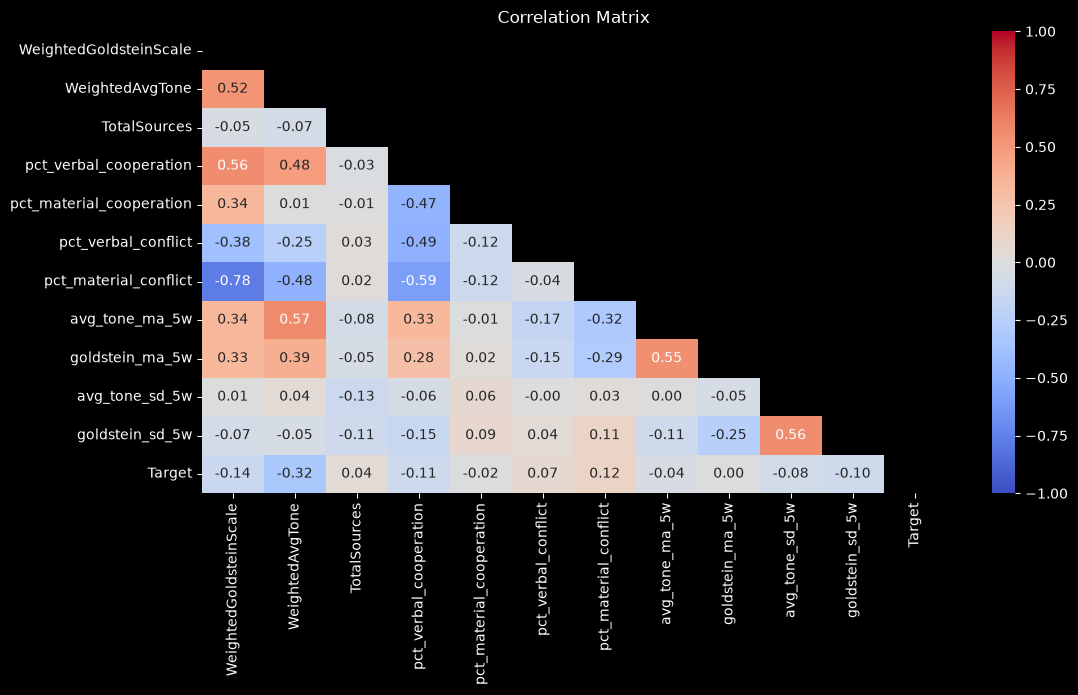

In [3]:
corr = df.select_dtypes(include="number").corr()
plt.figure(figsize=(12, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", mask=mask)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
%%writefile ml_boosting.py

import sys
import os
import datetime
import json

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from xgboost.spark import SparkXGBClassifier
from google.cloud import storage

def get_session():
    spark = (
        SparkSession.builder
        .appName("ML_job_gdelt_data")
        .getOrCreate()
    )
    return spark

def read_clean_data(input_data_table_id, spark):
    df = spark.read.format("bigquery").option("table", input_data_table_id).load()

    df_clean = df.dropna(
        subset=[
            "avg_tone_ma_5w",
            "goldstein_ma_5w",
            "Target",
            "goldstein_sd_5w",
            "avg_tone_sd_5w",
        ]
    )
    return df_clean

def prepare_split_data(df, cutoff_date="2025-01-01"):
    feature_cols = [
        col
        for col in df.columns
        if col not in ["Target", "Country_code", "week"]
    ]
    
    assembler = VectorAssembler(
        inputCols=feature_cols, outputCol="features", handleInvalid="keep"
    )
    df_transformed = assembler.transform(df)
    
    train_df = df_transformed.filter(df_transformed["week"] < cutoff_date).cache()
    test_df = df_transformed.filter(df_transformed["week"] >= cutoff_date).cache()

    train_df.count()
    test_df.count()
    
    return train_df, test_df, feature_cols

def train_model_XGB(train_df, workers=8):
    classifier = SparkXGBClassifier(
        label_col="Target",
        num_workers=workers,
        eval_metric="logloss",
        tree_method="hist",
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        scale_pos_weight=1.61
    )

    model = classifier.fit(train_df)

    return model
    
def evaluate_model(model, test_df):
    predictions = model.transform(test_df).cache()

    evaluator = BinaryClassificationEvaluator(
        labelCol="Target",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC",
    )
    tp, fp, tn, fn = 0, 0, 0, 0
    for row in cm_df:
        actual = int(row["Target"])
        pred = int(row["prediction"])
        count = row["count"]

        if actual == 1 and pred == 1:
            tp = count
        elif actual == 0 and pred == 1:
            fp = count
        elif actual == 0 and pred == 0:
            tn = count
        elif actual == 1 and pred == 0:
            fn = count

    total = tp + fp + tn + fn
    auc_score = round(float(evaluator.evaluate(predictions)), 4)
    accuracy = round(float((tp + tn) / total), 4) if total > 0 else 0.0
    specificity = round(float(tn / (tn + fp)), 4) if (tn + fp) > 0 else 0.0

    metrics = {
        "auc_roc": auc_score,
        "accuracy": accuracy,
        "specificity": specificity
    }
    
    return metrics

def export_metrics(metrics, bucket_name, blob_path):
    client = storage.Client()
    bucket = client.bucket(bucket_name)
    blob = bucket.blob(blob_path)
    
    blob.upload_from_string(
        data=json.dumps(metrics, indent=4),
        content_type="application/json"
    )

def save_model(bucket_name, model, feature_cols):
    booster = model.get_booster()
    
    booster.feature_names = feature_cols
    booster.feature_types = ["q"] * len(feature_cols)
    
    raw_json_str = booster.save_raw(raw_format="json").decode("utf-8")
    model_dict = json.loads(raw_json_str)
    
    if "learner" in model_dict:
        model_dict["learner"]["feature_names"] = feature_cols
        model_dict["learner"]["feature_types"] = ["q"] * len(feature_cols)
    
    updated_json_bytes = json.dumps(model_dict, indent=2).encode("utf-8")

    storage_client = storage.Client()
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob("models/xgboost_model.json")

    blob.upload_from_string(updated_json_bytes, content_type="application/json")

if __name__ == "__main__":
    PROJECT_ID = sys.argv[1]
    DATASET_ID = sys.argv[2]
    DM_TABLE_NAME = sys.argv[3]
    BUCKET_NAME = sys.argv[4].replace("gs://", "").strip("/")

    DM_TABLE_ID = f"{PROJECT_ID}.{DATASET_ID}.{DM_TABLE_NAME}"
    
    spark = get_session()

    try:
        df_clean = read_clean_data(DM_TABLE_ID, spark)
        tr_df, te_df, feature_cols = prepare_split_data(df_clean)
        model = train_model_XGB(tr_df, workers=8)

        metrics_blob_path = "metrics/xgboost_metrics.json"
        export_metrics(evaluate_model(model, te_df), BUCKET_NAME, metrics_blob_path)

        save_model(BUCKET_NAME, model, feature_cols)

    finally:
        spark.stop()

Overwriting ml_boosting.py


In [5]:
BATCH_ID = f"ml-boosting-{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}"
BLOB_PATH = "models/xgboost_model.json"
REGION = "europe-west1"
!gcloud storage cp ml_boosting.py gs://{BUCKET_NAME}/scripts/ml_boosting.py

!gcloud dataproc batches submit pyspark gs://{BUCKET_NAME}/scripts/ml_boosting.py \
    --batch={BATCH_ID} \
    --project={PROJECT_ID} \
    --region={REGION} \
    --deps-bucket=gs://{BUCKET_NAME} \
    --properties="spark.dynamicAllocation.enabled=false,spark.dataproc.driverEnv.PIP_PACKAGES=xgboost google-cloud-storage,spark.executorEnv.PIP_PACKAGES=xgboost google-cloud-storage" \
    -- {PROJECT_ID} {DATASET_ID} {DM_TABLE_NAME} {BUCKET_NAME}

Copying file://ml_boosting.py to gs://gdelt-ml-ccbd-mg-bucket/scripts/ml_boosting.py
  
............
Batch [ml-boosting-20260916-190512] submitted.
Using the default container image
time="2026-09-16T17:06:20Z" level=warning msg="cgroup_parent is not set. Use `runtime-config` to get the runtime cgroup driver"
time="2026-09-16T17:06:20Z" level=warning msg="cgroup_parent is not set. Use `runtime-config` to get the runtime cgroup driver"
Waiting for container log creation
PYSPARK_PYTHON=/opt/dataproc/conda/bin/python
Generating /home/spark/.pip/pip.conf
Configuring index-url as 'https://europe-python.pkg.dev/artifact-registry-python-cache/virtual-python/simple/'
JAVA_HOME=/usr/lib/jvm/temurin-17-jdk-amd64
SPARK_EXTRA_CLASSPATH=
:: loading settings :: file = /etc/spark/conf/ivysettings.xml
26/09/16 17:06:33 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-google-hadoop-file-system.properties,hadoop-metrics2.properties
26/09/16 17:06:33 INFO MetricsSystemImpl: Scheduled

In [6]:
from google.cloud import storage
import xgboost as xgb
from sklearn.metrics import roc_auc_score
import pandas as pd

st_client = storage.Client()

blob = st_client.bucket(BUCKET_NAME).blob(BLOB_PATH)

model_bytes = blob.download_as_bytes()

model = xgb.XGBClassifier()
model.load_model(bytearray(model_bytes))

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

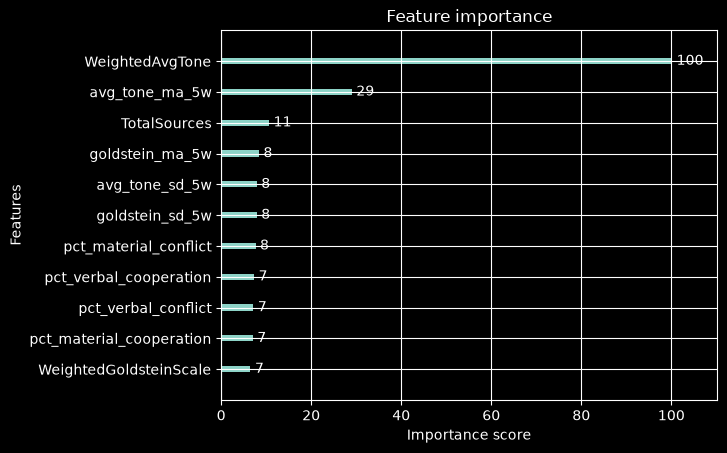

In [7]:
xgb.plot_importance(model, importance_type='gain',values_format="{v:.0f}")

In [8]:
df["week"] = pd.to_datetime(df["week"])

df = df.sort_values(["Country_code", "week"])

df["Prediction"] = 1 - (
    df.groupby("Country_code")["Target"].shift(1)
)

df_test = df[df["week"] >= pd.Timestamp("2025-01-01")].copy()

df_test = df_test.dropna(subset=["Prediction", "Target"])

auc = roc_auc_score(
    y_true=df_test["Target"],
    y_score=df_test["Prediction"]
)

targets_predictions_df = pd.crosstab(
    df_test["Target"],
    df_test["Prediction"]
)

tp = targets_predictions_df.loc[1, 1]
fp = targets_predictions_df.loc[0, 1]
tn = targets_predictions_df.loc[0, 0]
fn = targets_predictions_df.loc[1, 0]

total = tp + fp + tn + fn

accuracy = round((tp + tn) / total, 4)

specificity = round(tn / (tn + fp), 4)

print(f"Naive Model AUC: {auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Specificity: {specificity:.4f}")

Naive Model AUC: 0.6273
Accuracy: 0.6271
Specificity: 0.6200


In [9]:
!gcloud storage cat gs://{BUCKET_NAME}/metrics/xgboost_metrics.json

{
    "auc_roc": 0.7527,
    "accuracy": 0.6707,
    "specificity": 0.5433,
    "confusion_matrix": {
        "TN": 5230,
        "FP": 4396,
        "FN": 1814,
        "TP": 7418
    }
}
